# Uçuş Gecikmesi Tahmini — Makine Öğrenmesi Projesi

**Huawei Student Developers — Veri Bilimi ve Makine Öğrenmesi | Final Projesi**

**Problem:** Bir uçuşun *daha kalkmadan önce* elimizde olan bilgilerle (planlanan kalkış saati,
havayolu, kalkış/varış havaalanı, mesafe, o saatteki hava durumu) varışta **15 dakika veya daha fazla
gecikip gecikmeyeceğini** tahmin etmek.

**Veri seti:** `nycflights13` — 2013 yılında New York'un üç havaalanından (JFK, LGA, EWR) yapılan
336.776 uçuş + aynı havaalanlarının saatlik hava durumu kayıtları.

**Yöntemler:** Lojistik Regresyon, Karar Ağacı, Rastgele Orman.

## 1. Kütüphaneler ve ayarlar

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

warnings.filterwarnings("ignore")
RENK = ["#2E5A88", "#D96C3F", "#5B8C5A", "#8C5B8C"]
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 130, "font.size": 10,
                     "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
RASTGELE_TOHUM = 42

## 2. Veri setinin yüklenmesi

İki tablo kullanıyoruz: uçuş kayıtları ve saatlik hava durumu. Hava durumu tablosu, uçuşlara
*kalkış havaalanı + planlanan saat* üzerinden bağlanacak.

In [2]:
URL = "https://raw.githubusercontent.com/byuidatascience/data4python4ds/master/data-raw/"
flights = pd.read_csv(URL + "flights/flights.csv")
weather = pd.read_csv(URL + "weather/weather.csv", na_values=["NA"])

print("Uçuş tablosu :", flights.shape)
print("Hava durumu  :", weather.shape)
flights.head(3)

Uçuş tablosu : (336776, 19)
Hava durumu  : (26115, 15)


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z


In [3]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  str    
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  str    
 12  origin          336776 non-null  str    
 13  dest            336776 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute          33677

## 3. Hedef değişkenin tanımlanması

Havacılık literatüründe bir uçuş, planlanan varış saatinden **15 dakika ve üzeri** sapma
gösterdiğinde "gecikmeli" sayılır. Bu eşiği kullanarak sürekli `arr_delay` değişkenini ikili bir
hedefe çeviriyoruz.

`arr_delay` değeri boş olan kayıtlar **iptal edilmiş uçuşlardır**; bunlar farklı bir problem
(iptal tahmini) olduğu için veri setinden çıkarılıyor.

In [4]:
df = flights.dropna(subset=["arr_delay"]).copy()
df["is_delayed"] = (df["arr_delay"] >= 15).astype(int)

print("İptaller çıkarıldıktan sonra:", df.shape)
print("Gecikme oranı: %{:.2f}".format(100 * df["is_delayed"].mean()))
df["is_delayed"].value_counts()

İptaller çıkarıldıktan sonra: (327346, 20)
Gecikme oranı: %24.47


is_delayed
0    247246
1     80100
Name: count, dtype: int64

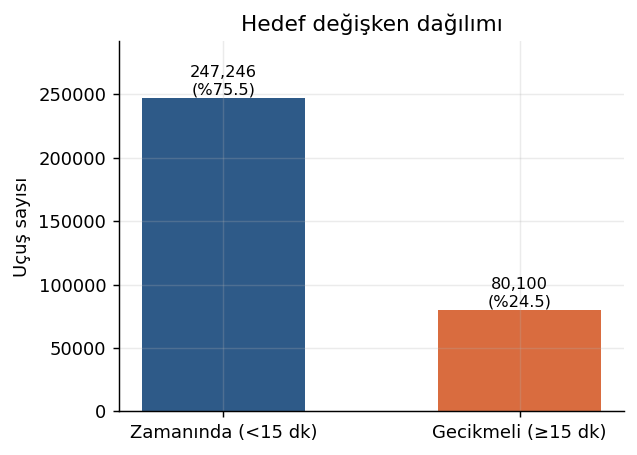

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.6))
sayim = df["is_delayed"].value_counts().sort_index()
ax.bar(["Zamanında (<15 dk)", "Gecikmeli (≥15 dk)"], sayim.values, color=RENK[:2], width=.55)
for i, v in enumerate(sayim.values):
    ax.text(i, v, f"{v:,}\n(%{100*v/len(df):.1f})", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Uçuş sayısı"); ax.set_title("Hedef değişken dağılımı")
ax.set_ylim(0, sayim.max() * 1.18)
fig.tight_layout(); fig.savefig("01_hedef_dagilimi.png"); plt.show()

## 4. Özellik mühendisliği ve veri sızıntısının önlenmesi

Bu projenin en kritik kararı burada: **`dep_delay`, `dep_time`, `air_time` ve `arr_time`
değişkenlerini kullanmıyoruz.**

Bu değişkenler uçuş kalktıktan *sonra* öğrenilir. Modele `dep_delay` verirsek doğruluk %90'ın
üzerine çıkar ama model işe yaramaz hale gelir: kalkışta 40 dakika geciken bir uçağın varışta da
gecikeceğini tahmin etmek için makine öğrenmesine ihtiyaç yoktur. Amacımız **kalkıştan önce**
karar destek sağlamak olduğu için yalnızca o anda bilinebilen bilgileri kullanıyoruz.

Ürettiğimiz değişkenler:
- `sched_dep_hour`, `sched_dep_min` — planlanan kalkış saati (gecikmelerin gün içinde biriktiği hipotezi)
- `day_of_week`, `is_weekend`, `month` — takvim etkileri
- `distance` — uçuş mesafesi
- `carrier`, `origin`, `dest` — havayolu ve havaalanları
- `temp`, `humid`, `wind_speed`, `precip`, `visib`, `pressure` — kalkış havaalanının o saatteki hava durumu

In [6]:
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df["day_of_week"] = df["date"].dt.dayofweek          # 0 = Pazartesi
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["sched_dep_hour"] = df["sched_dep_time"] // 100   # 1545 -> 15
df["sched_dep_min"] = df["sched_dep_time"] % 100     # 1545 -> 45

hava = weather[["origin", "time_hour", "temp", "humid", "wind_speed",
                "precip", "visib", "pressure"]].drop_duplicates(["origin", "time_hour"])
df = df.merge(hava, on=["origin", "time_hour"], how="left")

print("Hava durumu eşleşmeyen kayıt sayısı:", df["temp"].isna().sum())
df[["sched_dep_hour", "day_of_week", "distance", "temp", "precip", "is_delayed"]].head()

Hava durumu eşleşmeyen kayıt sayısı: 1544


,sched_dep_hour,day_of_week,distance,temp,precip,is_delayed
0,5,1,1400,39.02,0.0,0
1,5,1,1416,39.92,0.0,1
2,5,1,1089,39.02,0.0,1
3,5,1,1576,39.02,0.0,0
4,6,1,762,39.92,0.0,0


In [7]:
SAYISAL = ["distance", "sched_dep_hour", "sched_dep_min", "month", "day_of_week",
           "is_weekend", "temp", "humid", "wind_speed", "precip", "visib", "pressure"]
KATEGORIK = ["carrier", "origin", "dest"]

X = df[SAYISAL + KATEGORIK]
y = df["is_delayed"]
print("Öznitelik matrisi:", X.shape)
X.isna().sum()[lambda s: s > 0]

Öznitelik matrisi: (327346, 15)


temp           1544
humid          1544
wind_speed     1605
precip         1527
visib          1527
pressure      36142
dtype: int64

## 5. Keşifsel veri analizi

Modeli kurmadan önce, seçtiğimiz değişkenlerin hedefle gerçekten ilişkili olup olmadığını
görsel olarak kontrol ediyoruz.

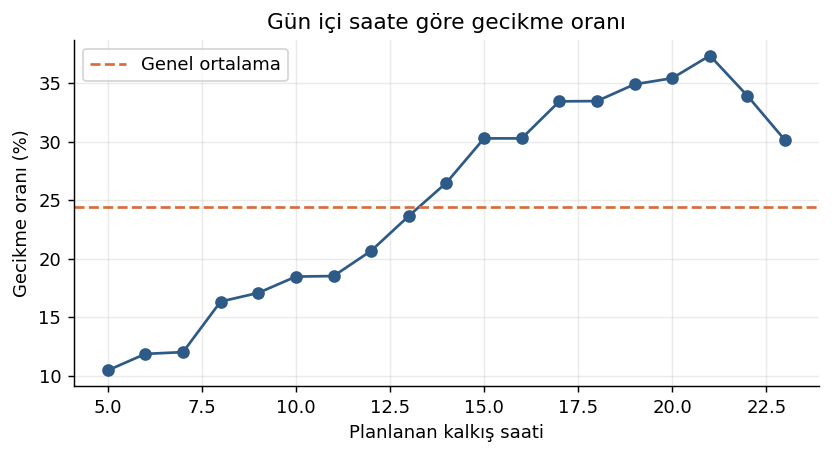

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
saat = df.groupby("sched_dep_hour")["is_delayed"].agg(["mean", "size"])
saat = saat[saat["size"] > 500]
ax.plot(saat.index, saat["mean"] * 100, marker="o", color=RENK[0])
ax.axhline(df["is_delayed"].mean() * 100, ls="--", color=RENK[1], label="Genel ortalama")
ax.set_xlabel("Planlanan kalkış saati"); ax.set_ylabel("Gecikme oranı (%)")
ax.set_title("Gün içi saate göre gecikme oranı"); ax.legend()
fig.tight_layout(); fig.savefig("02_saate_gore_gecikme.png"); plt.show()

Sabahın ilk uçuşlarında gecikme oranı **%10 civarındayken**, akşam saatlerinde **%35'in
üzerine** çıkıyor. Bunun nedeni gecikmelerin gün boyunca *birikmesi*: sabah geciken bir uçak,
aynı uçakla yapılacak sonraki uçuşları da geciktiriyor. Bu, modelimizin en güçlü sinyali olacak.

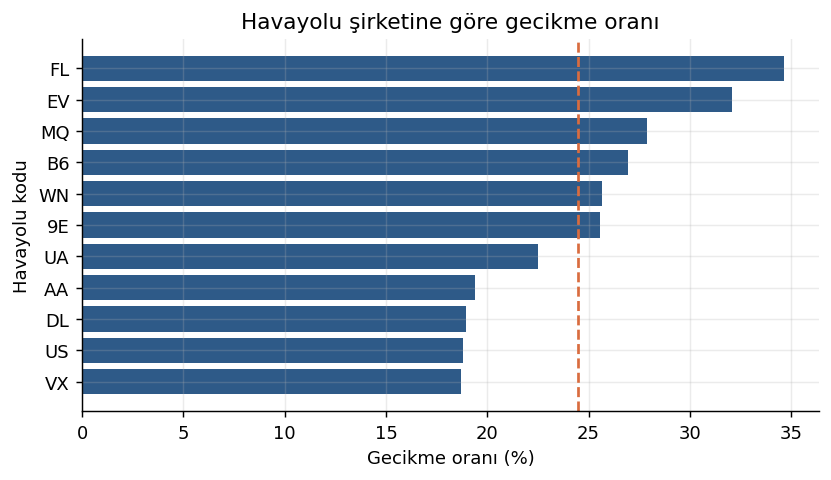

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
hy = df.groupby("carrier")["is_delayed"].agg(["mean", "size"])
hy = hy[hy["size"] > 2000].sort_values("mean")
ax.barh(hy.index, hy["mean"] * 100, color=RENK[0])
ax.axvline(df["is_delayed"].mean() * 100, ls="--", color=RENK[1])
ax.set_xlabel("Gecikme oranı (%)"); ax.set_ylabel("Havayolu kodu")
ax.set_title("Havayolu şirketine göre gecikme oranı")
fig.tight_layout(); fig.savefig("03_havayoluna_gore.png"); plt.show()

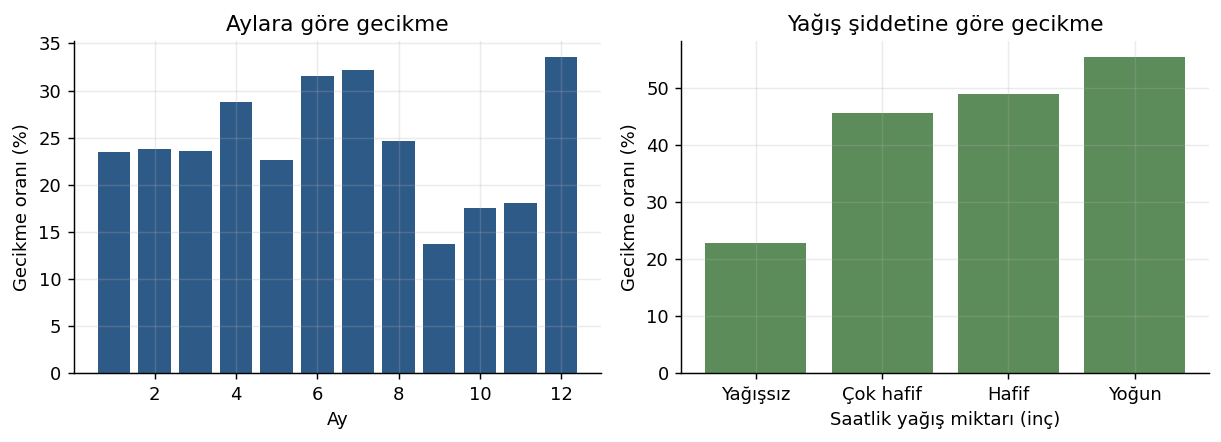

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5))

ay = df.groupby("month")["is_delayed"].mean() * 100
axes[0].bar(ay.index, ay.values, color=RENK[0])
axes[0].set_xlabel("Ay"); axes[0].set_ylabel("Gecikme oranı (%)")
axes[0].set_title("Aylara göre gecikme")

etiket = ["Yağışsız", "Çok hafif", "Hafif", "Yoğun"]
df["precip_bin"] = pd.cut(df["precip"], bins=[-.001, 0, .02, .1, 10], labels=etiket)
yagis = df.groupby("precip_bin", observed=True)["is_delayed"].mean() * 100
axes[1].bar(yagis.index.astype(str), yagis.values, color=RENK[2])
axes[1].set_xlabel("Saatlik yağış miktarı (inç)"); axes[1].set_ylabel("Gecikme oranı (%)")
axes[1].set_title("Yağış şiddetine göre gecikme")

fig.tight_layout(); fig.savefig("04_ay_ve_yagis.png"); plt.show()

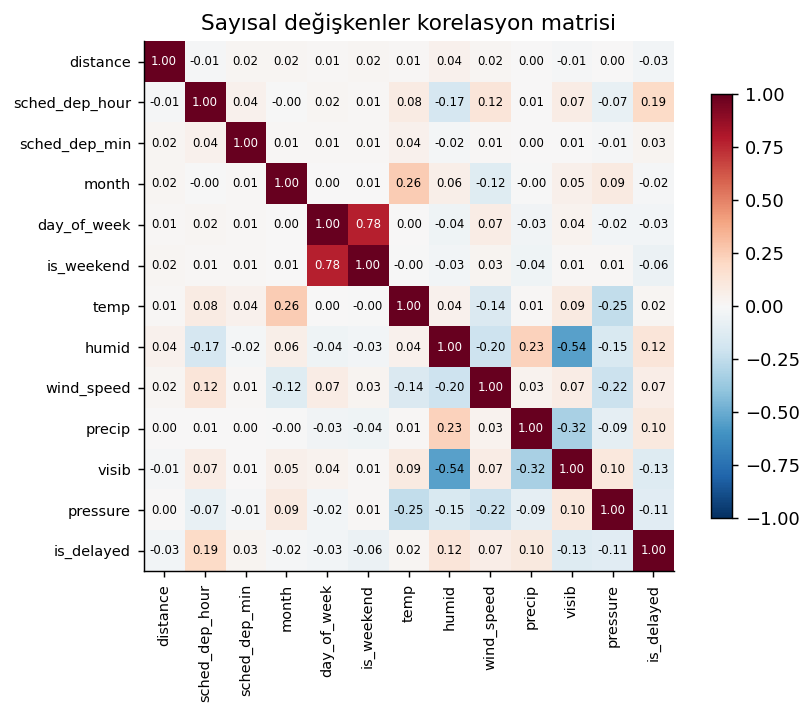

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.6))
kor = df[SAYISAL + ["is_delayed"]].corr()
im = ax.imshow(kor, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(kor))); ax.set_xticklabels(kor.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(kor))); ax.set_yticklabels(kor.columns, fontsize=8)
for i in range(len(kor)):
    for j in range(len(kor)):
        ax.text(j, i, f"{kor.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(kor.iloc[i, j]) > .55 else "black")
ax.grid(False); ax.set_title("Sayısal değişkenler korelasyon matrisi")
fig.colorbar(im, shrink=.8); fig.tight_layout()
fig.savefig("05_korelasyon.png"); plt.show()

Korelasyon matrisi tek başına yanıltıcı olabilir: en yüksek doğrusal korelasyon 0,19 (planlanan kalkış saati) ve
diğerlerinin hiçbiri 0,13'ü geçmiyor. Bu, "veri işe yaramaz" demek değil — ilişkilerin **doğrusal olmadığını**
gösteriyor. Ağaç tabanlı modelleri denememizin sebeplerinden biri de bu.

## 6. Veri hazırlama ve eğitim/test ayrımı

Tüm ön işleme adımlarını bir `Pipeline` içine koyuyoruz. Bunun nedeni sadece derli toplu kod değil:
ölçekleyiciyi ve doldurucuyu **yalnızca eğitim verisiyle** öğrenmek, test verisine ait bilgilerin
eğitime sızmasını engelliyor.

- Sayısal değişkenler: medyan ile doldurma + standartlaştırma
- Kategorik değişkenler: mod ile doldurma + One-Hot Encoding (100'den az görülen kategoriler tek bir grupta toplanıyor)
- Ayrım: %80 eğitim / %20 test, sınıf dağılımı korunarak (`stratify`)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=RASTGELE_TOHUM, stratify=y)

on_isleme = ColumnTransformer([
    ("sayisal", Pipeline([("doldur", SimpleImputer(strategy="median")),
                          ("olcek", StandardScaler())]), SAYISAL),
    ("kategorik", Pipeline([("doldur", SimpleImputer(strategy="most_frequent")),
                            ("kodla", OneHotEncoder(handle_unknown="ignore",
                                                    min_frequency=100))]), KATEGORIK)])

print("Eğitim:", X_train.shape, " Test:", X_test.shape)
print("Eğitimde gecikme oranı: %{:.2f}".format(100 * y_train.mean()))
print("Testte  gecikme oranı: %{:.2f}".format(100 * y_test.mean()))

Eğitim: (261876, 15)  Test: (65470, 15)
Eğitimde gecikme oranı: %24.47
Testte  gecikme oranı: %24.47


## 7. Modelleme

Üç yöntem karşılaştırılıyor:

| Model | Neden seçildi |
|---|---|
| **Lojistik Regresyon** | Yorumlanabilir, hızlı, doğrusal bir referans noktası |
| **Karar Ağacı** | Doğrusal olmayan ilişkileri ve etkileşimleri yakalar, karar kuralları okunabilir |
| **Rastgele Orman** | Çok sayıda ağacın oyu ile tek ağacın aşırı öğrenme sorununu azaltır |

Veri dengesiz olduğu için (yaklaşık 3'e 1) üç modelde de `class_weight="balanced"` kullanıyoruz;
aksi halde modeller her şeye "zamanında" demeyi öğrenir.

Ayrıca **temel referans (baseline)** olarak "hiçbir uçuş gecikmeyecek" diyen bir tahminciyi
tabloya ekliyoruz — modelin gerçekten değer katıp katmadığını ancak buna bakarak anlayabiliriz.

In [13]:
modeller = {
    "Lojistik Regresyon": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Karar Ağacı": DecisionTreeClassifier(max_depth=8, min_samples_leaf=200,
                                          class_weight="balanced", random_state=RASTGELE_TOHUM),
    "Rastgele Orman": RandomForestClassifier(n_estimators=200, max_depth=16,
                                             min_samples_leaf=50, class_weight="balanced",
                                             n_jobs=-1, random_state=RASTGELE_TOHUM),
}

satirlar = [{"Model": "Baseline (hepsi zamanında)", "Accuracy": accuracy_score(y_test, np.zeros(len(y_test))),
             "Precision": 0.0, "Recall": 0.0, "F1": 0.0, "ROC-AUC": 0.5}]
egitilmis, olasiliklar = {}, {}

for ad, model in modeller.items():
    boru = Pipeline([("on_isleme", on_isleme), ("model", model)])
    boru.fit(X_train, y_train)
    tahmin = boru.predict(X_test)
    olasilik = boru.predict_proba(X_test)[:, 1]
    egitilmis[ad], olasiliklar[ad] = boru, olasilik
    satirlar.append({"Model": ad,
                     "Accuracy": accuracy_score(y_test, tahmin),
                     "Precision": precision_score(y_test, tahmin),
                     "Recall": recall_score(y_test, tahmin),
                     "F1": f1_score(y_test, tahmin),
                     "ROC-AUC": roc_auc_score(y_test, olasilik)})
    print(f"{ad} eğitildi.")

sonuclar = pd.DataFrame(satirlar).round(3)
sonuclar

Lojistik Regresyon eğitildi.


Karar Ağacı eğitildi.


Rastgele Orman eğitildi.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline (hepsi zamanında),0.755,0.000,0.000,0.000,0.500
1,Lojistik Regresyon,0.654,0.379,0.646,0.478,0.704
2,Karar Ağacı,0.715,0.435,0.554,0.488,0.720
3,Rastgele Orman,0.719,0.448,0.634,0.525,0.758


### Sonuç tablosu nasıl okunmalı?

Baseline'ın doğruluğu **%75,5** — yani hiçbir şey öğrenmeyen bir tahminci bile bu skoru alıyor.
Rastgele Orman'ın doğruluğu bundan *düşük* görünüyor, ama gecikmeli uçuşların **%63'ünü yakalıyor**
(recall), baseline ise sıfırını yakalıyor. Dengesiz veri setlerinde doğruluğa bakarak model seçmenin
neden hatalı olduğunun somut örneği bu. Karşılaştırmayı **F1 ve ROC-AUC** üzerinden yapıyoruz.

## 8. Değerlendirme

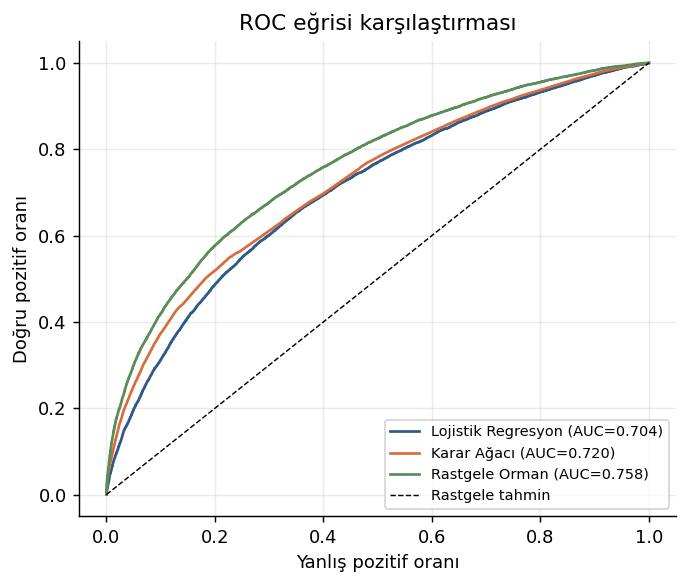

In [14]:
fig, ax = plt.subplots(figsize=(5.4, 4.6))
for (ad, olasilik), renk in zip(olasiliklar.items(), RENK):
    fpr, tpr, _ = roc_curve(y_test, olasilik)
    ax.plot(fpr, tpr, color=renk, label=f"{ad} (AUC={roc_auc_score(y_test, olasilik):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=.8, label="Rastgele tahmin")
ax.set_xlabel("Yanlış pozitif oranı"); ax.set_ylabel("Doğru pozitif oranı")
ax.set_title("ROC eğrisi karşılaştırması"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig("06_roc.png"); plt.show()

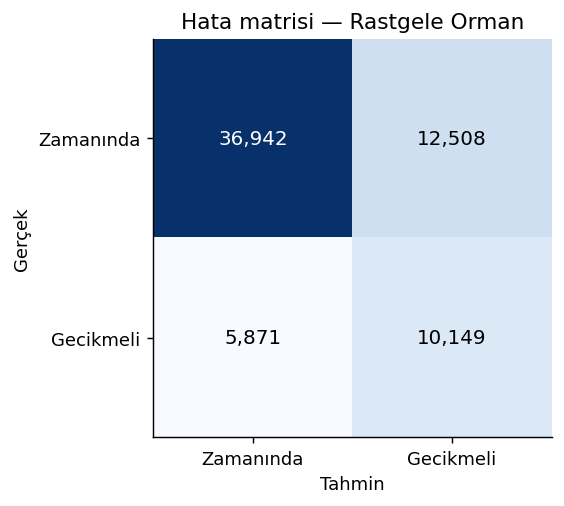

              precision    recall  f1-score   support

   Zamanında      0.863     0.747     0.801     49450
   Gecikmeli      0.448     0.634     0.525     16020

    accuracy                          0.719     65470
   macro avg      0.655     0.690     0.663     65470
weighted avg      0.761     0.719     0.733     65470



In [15]:
en_iyi = sonuclar[sonuclar.Model != "Baseline (hepsi zamanında)"].sort_values("ROC-AUC").iloc[-1]["Model"]
hm = confusion_matrix(y_test, egitilmis[en_iyi].predict(X_test))

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(hm, cmap="Blues")
etiketler = ["Zamanında", "Gecikmeli"]
ax.set_xticks([0, 1]); ax.set_xticklabels(etiketler)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiketler)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{hm[i, j]:,}", ha="center", va="center", fontsize=11,
                color="white" if hm[i, j] > hm.max() / 2 else "black")
ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek"); ax.grid(False)
ax.set_title(f"Hata matrisi — {en_iyi}")
fig.tight_layout(); fig.savefig("07_hata_matrisi.png"); plt.show()

print(classification_report(y_test, egitilmis[en_iyi].predict(X_test),
                            target_names=etiketler, digits=3))

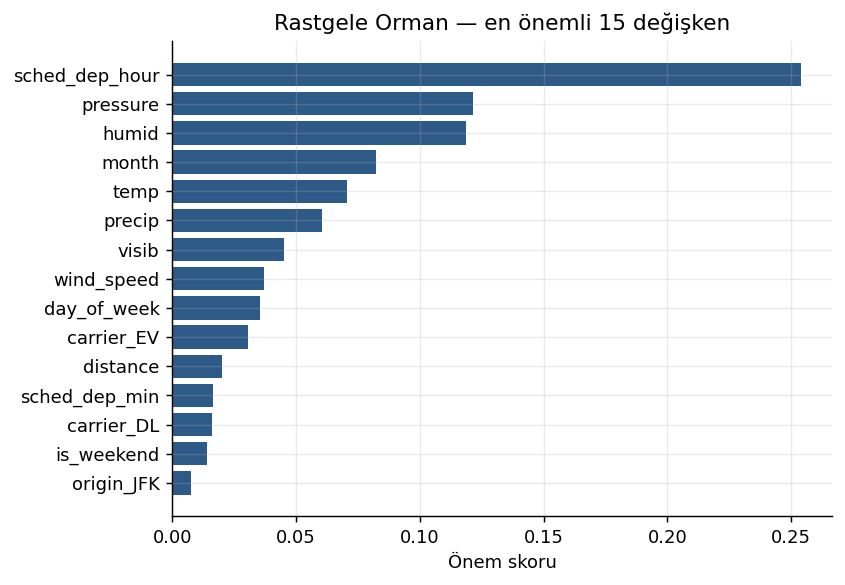

sayisal__sched_dep_hour    0.2538
sayisal__pressure          0.1215
sayisal__humid             0.1187
sayisal__month             0.0824
sayisal__temp              0.0706
sayisal__precip            0.0603
sayisal__visib             0.0453
sayisal__wind_speed        0.0369
sayisal__day_of_week       0.0353
kategorik__carrier_EV      0.0306
dtype: float64

In [16]:
orman = egitilmis["Rastgele Orman"]
isimler = orman.named_steps["on_isleme"].get_feature_names_out()
onem = pd.Series(orman.named_steps["model"].feature_importances_, index=isimler).sort_values()[-15:]

fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.barh([i.split("__")[-1] for i in onem.index], onem.values, color=RENK[0])
ax.set_xlabel("Önem skoru"); ax.set_title("Rastgele Orman — en önemli 15 değişken")
fig.tight_layout(); fig.savefig("08_degisken_onemi.png"); plt.show()

onem.sort_values(ascending=False).head(10).round(4)

## 9. Çıkarımlar

**1. En güçlü sinyal saat, hava durumu değil.** Değişken önem sıralamasında `sched_dep_hour` tek
başına toplam önemin dörtte birini alıyor. Gecikmeler gün boyunca biriktiği için, aynı uçağın akşam
seferi sabah seferinden çok daha risklidir.

**2. Hava durumu ikinci sırada ama tek başına yeterli değil.** Basınç, nem ve yağış birlikte önemli
bir katkı sağlıyor; yağışlı saatlerde gecikme oranı belirgin biçimde yükseliyor. Buna karşılık
hava durumu değişkenlerinin hedefle doğrusal korelasyonu çok düşük — etki eşik davranışı gösteriyor,
bu yüzden ağaç tabanlı modeller doğrusal modeli geçiyor.

**3. Havayolu seçimi ölçülebilir bir fark yaratıyor.** Bölgesel taşıyıcıların gecikme oranı, büyük
taşıyıcıların iki katına yaklaşıyor.

**4. Modelin sınırları.** ROC-AUC ~0,76 iyi bir başlangıç ama mükemmel değil. Eksik olan bilgi,
uçağın *önceki seferindeki durumu* (kuyruk numarası bazlı gecikme zinciri), hava trafik kontrol
gecikmeleri ve varış havaalanının o andaki yoğunluğu. Bir sonraki adım bu değişkenleri üretmek olurdu.

**5. Pratik kullanım.** Model, kalkıştan önce risk skoru üreterek yolcuya "bu uçuşun gecikme
olasılığı yüksek" uyarısı verebilir veya havayolunun operasyon ekibinin riskli seferlere önceden
kaynak ayırmasını sağlayabilir. Karar eşiği (varsayılan 0,5) uygulamaya göre değiştirilebilir:
yanlış alarmın maliyeti düşükse eşiği indirip daha fazla gecikme yakalanabilir.